# HR Attrition Analysis

## Introduction

Employee attrition is one of the major challenges that organizations face because it can impact productivity, increase hiring costs, and affect team stability. Understanding the reasons behind employee turnover is important for improving employee satisfaction and retention.

In this project, we analyze the **IBM HR Analytics Employee Attrition dataset** to explore the key factors that influence employee attrition. The analysis focuses on identifying patterns and relationships between attrition and different employee characteristics such as age, income, overtime, and job role.

The project includes several steps such as **data exploration, data cleaning, exploratory data analysis (EDA), and machine learning modeling** to build a predictive model that can estimate the likelihood of employee attrition.

The insights generated from this analysis can help HR departments make data-driven decisions to improve employee retention and organizational performance.

### Project Objectives

- Analyze employee attrition patterns  
- Identify factors that influence employee turnover  
- Explore relationships between attrition and employee attributes  
- Build a machine learning model to predict employee attrition

## Import Libraries

In [1]:
# Import libraries for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv(r"D:\gergess_magdy\Data Analysis\projects_Data_analysis\3_Python_project\1_HR_Project\Data\WA_Fn-UseC_-HR-Employee-Attrition.CSV")

# Display the first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Data Overview

In [9]:
# Display dataset information (columns, data types, non-null counts)
df.info()

# Display statistical summary of numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [6]:
# Display the shape of the dataset (rows, columns)
df.shape

(1470, 35)

In [5]:
# Count of unique values per column
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [7]:
# Check for missing values
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Data Cleaning

In [3]:
# Drop columns that are not useful for analysis
columns_to_drop = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18']
df = df.drop(columns=columns_to_drop, errors='ignore')

# Check the updated columns
print("Updated Columns:", df.columns.tolist())

Updated Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [4]:
# Convert Attrition column from text to numeric
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Verify encoding
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [10]:
# Verify no missing values exist after cleaning
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

df.dtypes

## Exploratory Data Analysis (EDA)

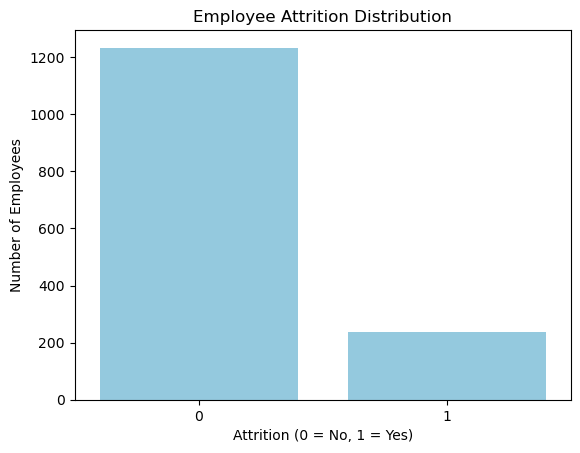

In [5]:
# Plot Attrition Distribution
sns.countplot(data=df, x='Attrition', color='skyblue')
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Number of Employees')
plt.show()

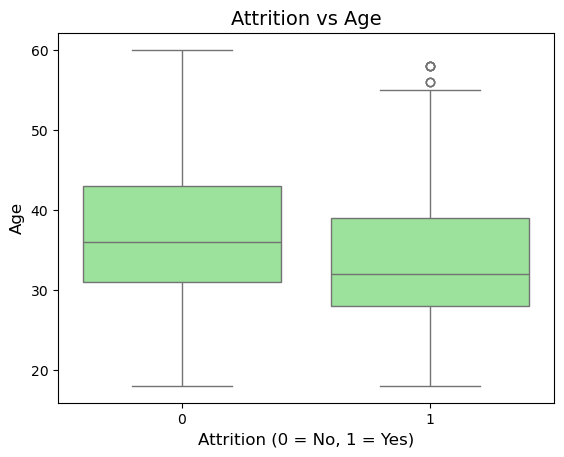

In [6]:
# Plot Attrition vs Age
sns.boxplot(x='Attrition', y='Age', data=df, color='lightgreen')
plt.title('Attrition vs Age', fontsize=14)
plt.xlabel('Attrition (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.show()

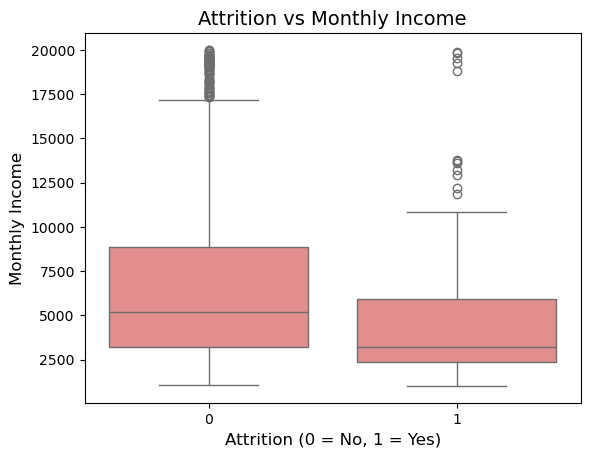

In [7]:
# Plot Attrition vs Monthly Income
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, color='lightcoral')
plt.title('Attrition vs Monthly Income', fontsize=14)
plt.xlabel('Attrition (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Monthly Income', fontsize=12)
plt.show()

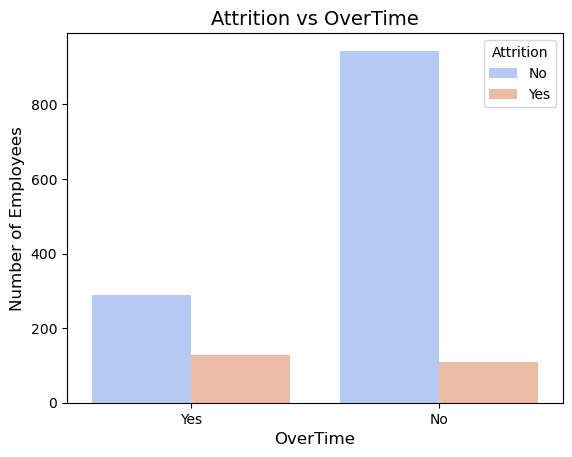

In [8]:
# Plot Attrition vs OverTime
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='coolwarm')
plt.title('Attrition vs OverTime', fontsize=14)
plt.xlabel('OverTime', fontsize=12)
plt.ylabel('Number of Employees', fontsize=12)
plt.legend(title='Attrition', labels=['No','Yes'])
plt.show()

## Correlation Analysis

To understand which features are most related to employee attrition, we calculated the correlation between all numerical variables and the target variable (Attrition).

The visualization below shows the top features that have the strongest relationship with employee attrition.

In [9]:
corr = df.corr(numeric_only=True)['Attrition'].sort_values(ascending=False)

corr

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition, dtype: float64

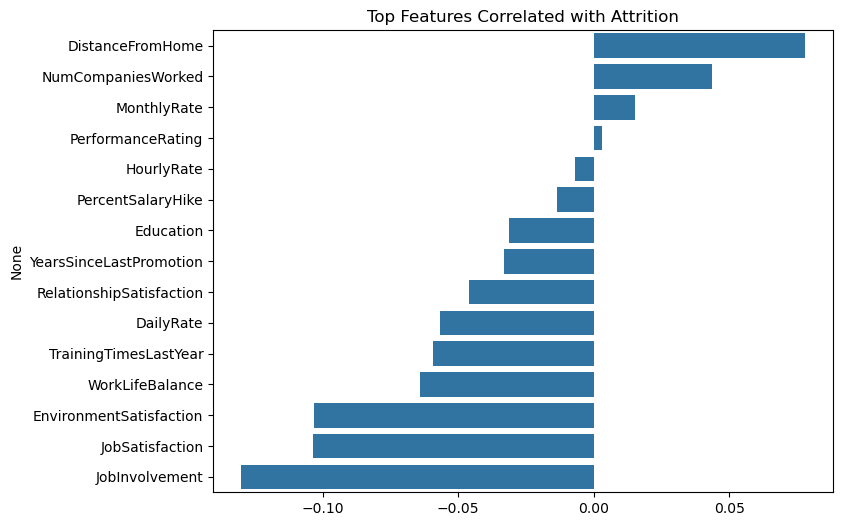

In [10]:
top_corr = corr[1:16]

plt.figure(figsize=(8,6))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Attrition")

plt.show()

## Key Insights from EDA

Based on the exploratory data analysis, 
here are the main observations regarding employee attrition:

1. **Attrition Rate is Low**  
   Most employees stayed with the company, with a smaller proportion leaving (Attrition = 1).

2. **Younger Employees Tend to Leave More**  
   Boxplots show that employees who leave are generally younger compared to those who stay.

3. **Lower Monthly Income is Associated with Higher Attrition**  
   Employees with lower salaries are more likely to leave, indicating pay is a key factor.

4. **Overtime Increases Attrition Risk**  
   Employees working overtime have a higher likelihood of leaving, suggesting workload affects retention.

5. **Attrition is Less Dependent on Age after 40**  
   Employees above 40 years old show a lower turnover rate, indicating stability with experience.

6. **Work-Life Balance Factors May Influence Attrition**  
   Although not directly visualized, the correlation with Overtime suggests that work-life balance is important.

7. **Insights Can Inform HR Decisions**  
   These patterns can help HR focus on retention strategies, salary reviews, and overtime management.

## Predicting Employee Attrition with XGBoost

In this section, we build a machine learning model using **XGBoost** to predict which employees are likely to leave the company.  

In [21]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# Split into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Check class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 Attrition
0    986
1    190
Name: count, dtype: int64
After SMOTE:
 Attrition
0    986
1    986
Name: count, dtype: int64


In [22]:
# Initialize and train XGBoost on balanced data
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_res, y_train_res)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [23]:
# Predict probabilities on test set
y_probs = xgb_model.predict_proba(X_test)[:, 1]

# Apply custom threshold
threshold = 0.3
y_pred = (y_probs >= threshold).astype(int)

# Evaluate results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8401360544217688
Confusion Matrix:
 [[227  20]
 [ 27  20]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91       247
           1       0.50      0.43      0.46        47

    accuracy                           0.84       294
   macro avg       0.70      0.67      0.68       294
weighted avg       0.83      0.84      0.83       294



## Feature Importance Analysis

In [24]:
# Create a dataframe for feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Show top 10 most important features
feature_importance.head(10)

,Feature,Importance
15,StockOptionLevel,0.123562
41,MaritalStatus_Married,0.072798
26,Department_Sales,0.070440
7,JobLevel,0.062096
42,MaritalStatus_Single,0.061697
33,JobRole_Human Resources,0.044742
8,JobSatisfaction,0.042804
25,Department_Research & Development,0.040448
31,EducationField_Technical Degree,0.032943
29,EducationField_Medical,0.027608


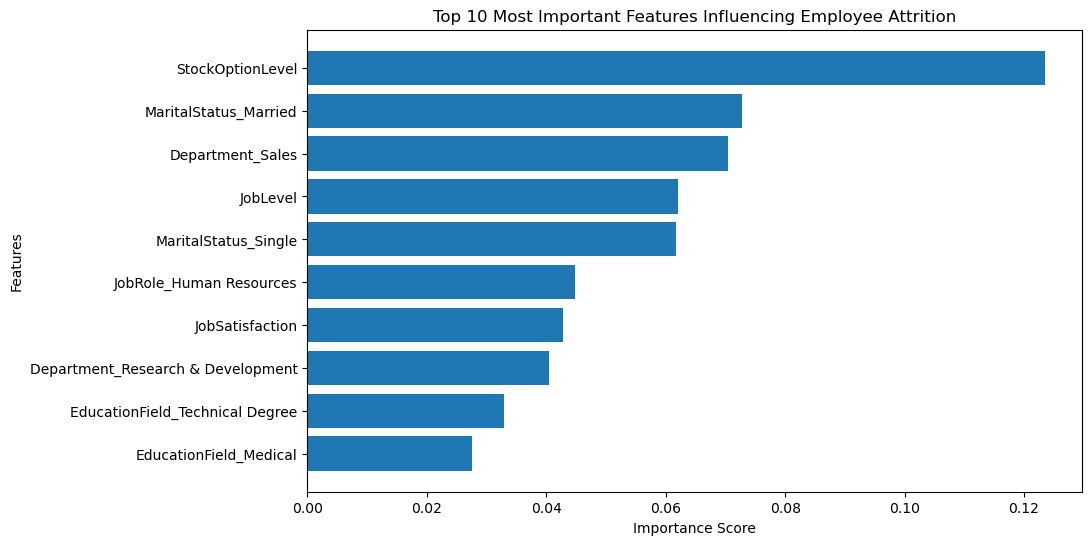

In [25]:
# Plot top 10 important features
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.gca().invert_yaxis()

plt.title("Top 10 Most Important Features Influencing Employee Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

## Key Drivers of Employee Attrition

Based on the XGBoost feature importance analysis, several factors appear to play a significant role in predicting employee attrition.

### 1. Stock Option Level
This is the most influential feature in the model. Employees with lower stock option benefits may be more likely to leave the company, suggesting that long-term financial incentives can improve retention.

### 2. Marital Status
Both "Married" and "Single" categories appear among the most important features, indicating that personal life circumstances may influence job stability and turnover behavior.

### 3. Department
Employees in the **Sales** and **Research & Development** departments show notable influence on attrition predictions. This may suggest different workload levels or career pressures across departments.

### 4. Job Level
Job level is an important factor, which may indicate that employees in certain seniority levels are more likely to leave due to career growth opportunities or job expectations.

### 5. Job Satisfaction
Lower job satisfaction is strongly associated with higher attrition risk, highlighting the importance of employee engagement and workplace satisfaction.

### 6. Education Field
Certain education backgrounds such as **Technical Degree** and **Medical fields** appear to influence attrition predictions, possibly reflecting varying job market demand for these skills.

## Business Recommendations

Based on the analysis and machine learning results, several strategies can help reduce employee attrition:

1. Improve financial incentives such as stock options and compensation packages.
2. Monitor workload and overtime, especially in high-pressure departments like Sales.
3. Enhance job satisfaction through employee engagement programs.
4. Focus on retention strategies for employees in early career stages.
5. Provide career development opportunities and training programs.

Implementing these strategies can help organizations improve employee retention and reduce turnover.